<a href="https://colab.research.google.com/github/Prathibha-bm/take_it_smart/blob/main/week11_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Customer Segmentation using K-Means Clustering**

**Problem Statement**

In today’s competitive market, businesses need to understand their customers to deliver personalized experiences and increase revenue. However, customers differ in terms of age,income, purchasing habits, and loyalty, making it difficult to target them effectively.

This project aims to analyze customer purchasing behavior using features such as age, annual income, purchase amount, purchase frequency, region, and loyalty score. The objective is to group customers into meaningful segments based on their similarities.

By performing customer segmentation, businesses can:

● Identify high-value and low-value customers

● Design targeted marketing strategies

● Improve customer retention and loyalty

● Optimize product recommendations


#1. Understanding the Problem

**Objective**

Segment customers into groups based on purchasing behavior.

-Business Goal

-Identify high-value customers

-Improve marketing strategy

-Increase customer loyalty

-Provide personalized recommendations

#2. Understanding the Problem**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#3. Import Libraries & Load Data

● Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [ ]:
df = pd.read_csv("/content/Customer Purchasing Behaviors.csv")

df.head()

,user_id,age,annual_income,purchase_amount,loyalty_score,region,purchase_frequency
0,1,25,45000,200,4.5,North,12
1,2,34,55000,350,7.0,South,18
2,3,45,65000,500,8.0,West,22
3,4,22,30000,150,3.0,East,10
4,5,29,47000,220,4.8,North,13


#4. Basic Data Checks

● Check shape, datatypes

● Handle missing values

● Remove duplicates

Shape

In [ ]:
#dataset shape
df.shape

(238, 7)

In [ ]:
#Datatype
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   user_id             238 non-null    int64  
 1   age                 238 non-null    int64  
 2   annual_income       238 non-null    int64  
 3   purchase_amount     238 non-null    int64  
 4   loyalty_score       238 non-null    float64
 5   region              238 non-null    object 
 6   purchase_frequency  238 non-null    int64  
dtypes: float64(1), int64(5), object(1)
memory usage: 13.1+ KB


In [ ]:
#Statistical Summary
df.describe()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency
count,238.000000,238.000000,238.000000,238.000000,238.000000,238.000000
mean,119.500000,38.676471,57407.563025,425.630252,6.794118,19.798319
std,68.848868,9.351118,11403.875717,140.052062,1.899047,4.562884
min,1.000000,22.000000,30000.000000,150.000000,3.000000,10.000000
25%,60.250000,31.000000,50000.000000,320.000000,5.500000,17.000000
50%,119.500000,39.000000,59000.000000,440.000000,7.000000,20.000000
75%,178.750000,46.750000,66750.000000,527.500000,8.275000,23.000000
max,238.000000,55.000000,75000.000000,640.000000,9.500000,28.000000


In [ ]:
#missing values
df.isnull().sum()

,0
user_id,0
age,0
annual_income,0
purchase_amount,0
loyalty_score,0
region,0
purchase_frequency,0


In [ ]:
#Remove Missing Values (if any)
df = df.drop_duplicates()

#5. Exploratory Data Analysis (EDA)

**Univariate Analysis**

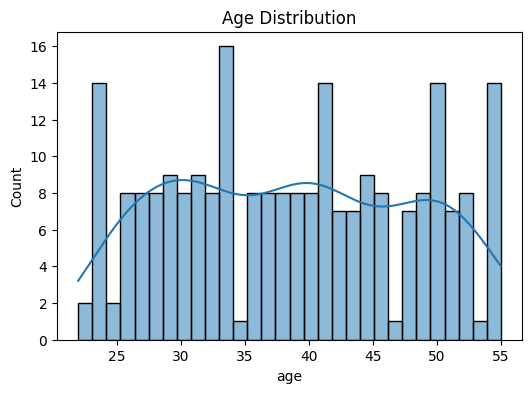

In [ ]:
#Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

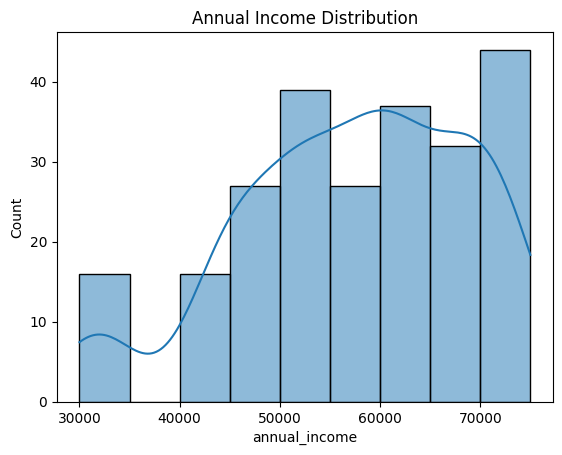

In [ ]:
#Annual Income Distribution
sns.histplot(df['annual_income'], kde=True)
plt.title("Annual Income Distribution")
plt.show()

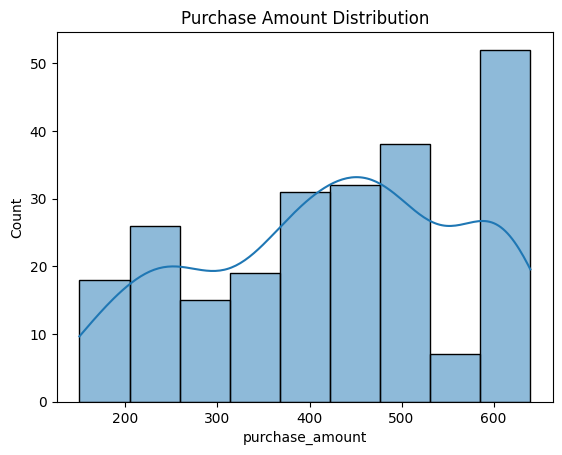

In [ ]:
#Purchase Amount Distribution
sns.histplot(df['purchase_amount'], kde=True)
plt.title("Purchase Amount Distribution")
plt.show()

#**Bivariate Analysis**

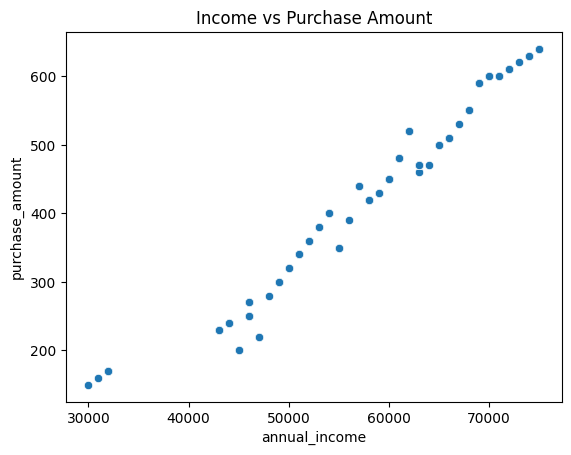

In [ ]:
#Income vs Purchase
sns.scatterplot(
    x='annual_income',
    y='purchase_amount',
    data=df)
plt.title("Income vs Purchase Amount")
plt.show()

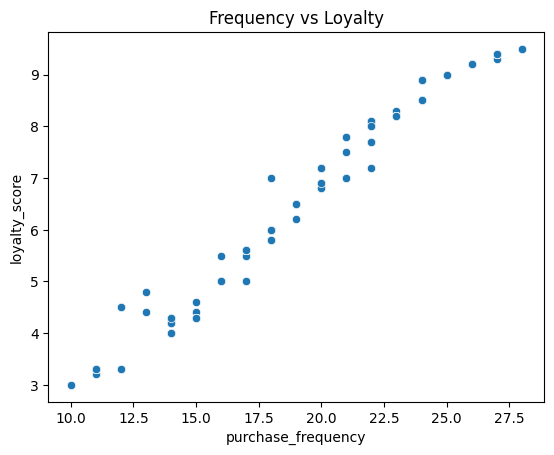

In [ ]:
#Frequency vs Loyalty
sns.scatterplot(
    x='purchase_frequency',
    y='loyalty_score',
    data=df)
plt.title("Frequency vs Loyalty")
plt.show()

#Identify Patterns and Trends

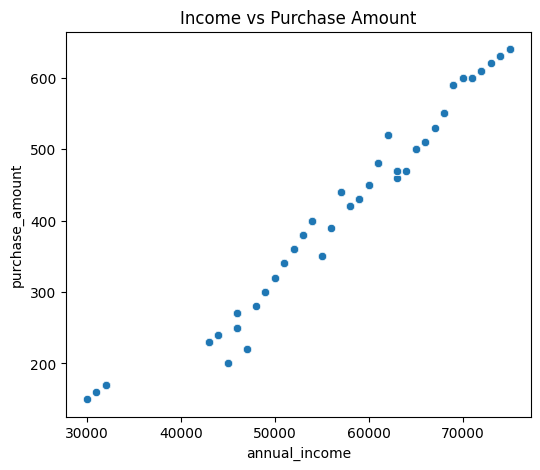

In [ ]:
#Income vs Purchase Amount
plt.figure(figsize=(6,5))

sns.scatterplot(
    x='annual_income',
    y='purchase_amount',
    data=df
)

plt.title("Income vs Purchase Amount")
plt.show()

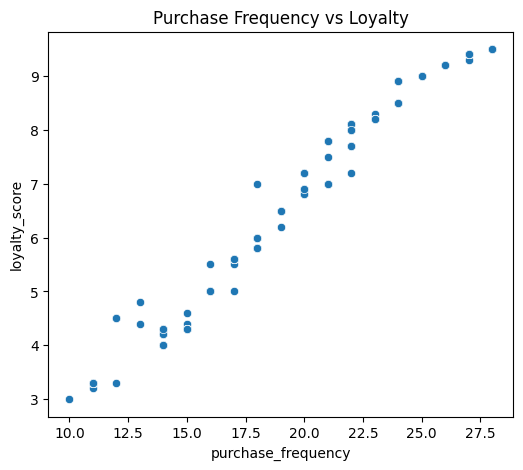

In [ ]:
#Purchase Frequency vs Loyalty
plt.figure(figsize=(6,5))

sns.scatterplot(
    x='purchase_frequency',
    y='loyalty_score',
    data=df
)

plt.title("Purchase Frequency vs Loyalty")
plt.show()

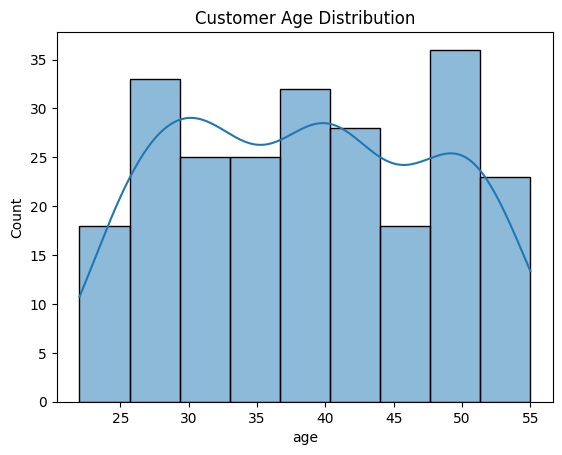

In [ ]:
#Age Distribution Trend
sns.histplot(df['age'], kde=True)
plt.title("Customer Age Distribution")
plt.show()

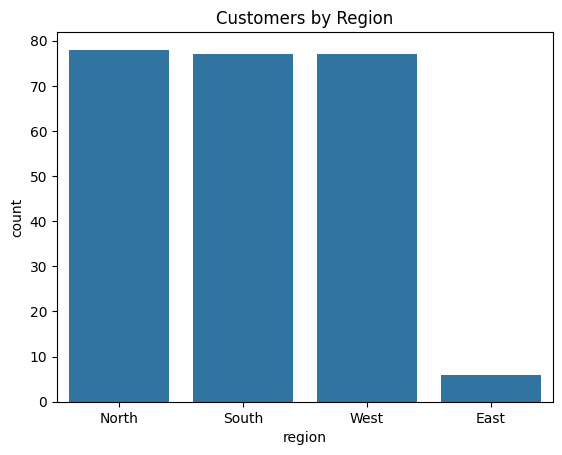

In [ ]:
#Region-wise Customer Distribution
sns.countplot(x='region', data=df)
plt.title("Customers by Region")
plt.show()

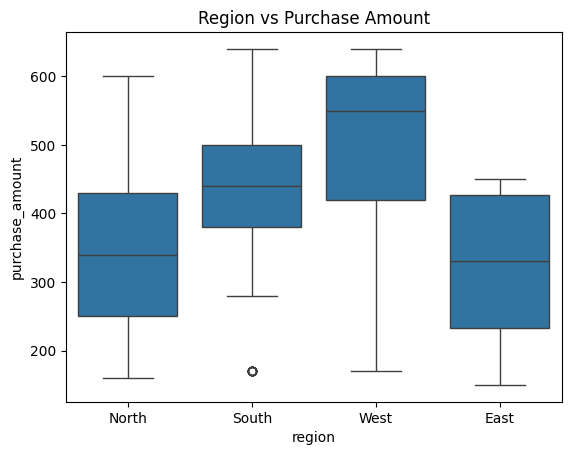

In [ ]:
#Spending Behavior Pattern
sns.boxplot(x='region', y='purchase_amount', data=df)
plt.title("Region vs Purchase Amount")
plt.show()

#**Data Preprocessing**

5. Data Preprocessing

In [ ]:
df = pd.get_dummies(df, columns=['region'], drop_first=True)

In [ ]:
scaler = StandardScaler()

#Feature Selection

In [ ]:
features = df[
    [
        'annual_income',
        'purchase_amount',
        'purchase_frequency',
        'loyalty_score'
    ]
]

In [ ]:
scaled_features = scaler.fit_transform(features)

Apply K-Means Clustering

In [ ]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

Plot Elbow Curve

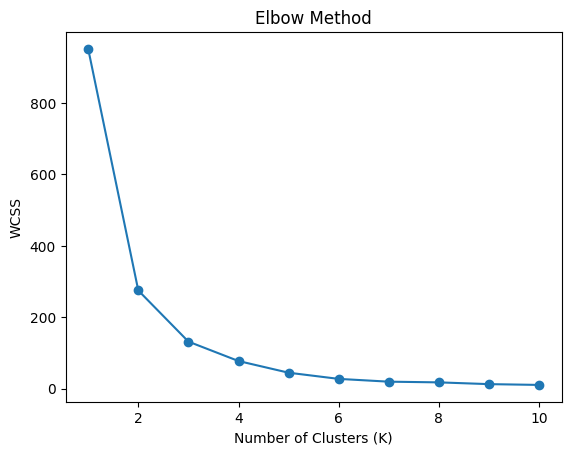

In [ ]:
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

#Train Final Model

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)

df['Cluster'] = kmeans.fit_predict(scaled_features)

#Visualize Customer Segments

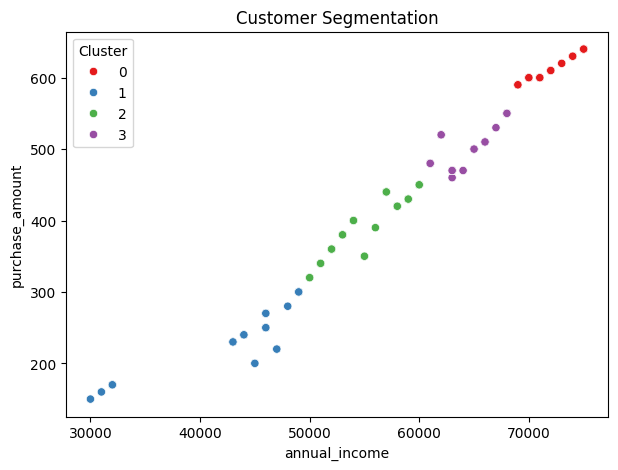

In [ ]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df['annual_income'],
    y=df['purchase_amount'],
    hue=df['Cluster'],
    palette='Set1'
)

plt.title("Customer Segmentation")
plt.show()

#9.Cluster Analysis

In [ ]:
df.groupby('Cluster').mean()

,user_id,age,annual_income,purchase_amount,loyalty_score,purchase_frequency,region_North,region_South,region_West
Cluster,,,,,,,,,
0,126.115385,51.557692,71557.692308,609.807692,9.142308,25.711538,0.134615,0.173077,0.692308
1,111.610169,26.779661,41915.254237,230.338983,4.091525,13.508475,0.627119,0.254237,0.067797
2,121.438356,35.342466,55136.986301,396.986301,6.415068,18.958904,0.315068,0.342466,0.315068
3,119.129630,43.777778,63777.777778,500.370370,7.998148,22.111111,0.203704,0.518519,0.259259
